# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

In [3]:
data = pd.read_csv('data/banknote_authentication.csv' )

In [4]:
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


In [5]:
seed = 31287
features = ['a1', 'a2', 'a3']

data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data['counterfeit'], random_state=seed)
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

pi1 = lbls_train.mean()
pi0 = 1 - pi1

# Helper functions for GMDA
def make_pdf(cmp):
    n_cmp = cmp.n_components
    dists = [st.multivariate_normal(cmp.means_[i], cmp.covariances_[i]) for i in range(n_cmp)]
    def pdf(x):
        p = 0.0
        for i in range(n_cmp):
            p += cmp.weights_[i] * dists[i].pdf(x)
        return p
    return pdf

def make_predict_proba(cmp0, cmp1, pi0=0.5, pi1=0.5):
    pdf0 = make_pdf(cmp0)
    pdf1 = make_pdf(cmp1)
    def p(x):
        p0 = pi0 * pdf0(x)
        p1 = pi1 * pdf1(x)
        return p1 / (p1 + p0)
    return p

# Also reproduce QDA and GMDA(2) from Part A & B for use in Part D
train_0 = data_train[lbls_train == 0][features].values
train_1 = data_train[lbls_train == 1][features].values

# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(data_train[features], lbls_train)
qda_proba_test = qda.predict_proba(data_test[features])[:, 1]
qda_auc = roc_auc_score(lbls_test, qda_proba_test)
fprs_qda, tprs_qda, thds_qda = roc_curve(lbls_test, qda_proba_test)

# GMDA (2 components)
gm0_2 = GaussianMixture(n_components=2, random_state=seed).fit(train_0)
gm1_2 = GaussianMixture(n_components=2, random_state=seed).fit(train_1)
mgda2 = make_predict_proba(gm0_2, gm1_2, pi0=pi0, pi1=pi1)
mgda2_test_proba = mgda2(data_test[features].values)
mgda2_auc = roc_auc_score(lbls_test, mgda2_test_proba)
fprs_mgda2, tprs_mgda2, thds_mgda2 = roc_curve(lbls_test, mgda2_test_proba)

print(f"QDA AUC: {qda_auc:.4f}")
print(f"GMDA(2) AUC: {mgda2_auc:.4f}")

QDA AUC: 0.8754
GMDA(2) AUC: 0.9405


## Problem 

### C.

Use k-fold cross validation to find the optimal number of gaussian components for each class. As before calculate the confusion matrix, AUC score and plot the ROC curve for the best classifier. Assume that maximal number of components in each class is 12.  

__Hint__ use the `StratifiedKFold` function from scikit-learn library to generate folds. 

Best n_components: class 0 = 12, class 1 = 8
Best CV AUC: 0.9923

Best GMDA Confusion Matrix (normalized):
[[0.95081967 0.04918033]
 [0.10204082 0.89795918]]

Best GMDA AUC: 0.9874


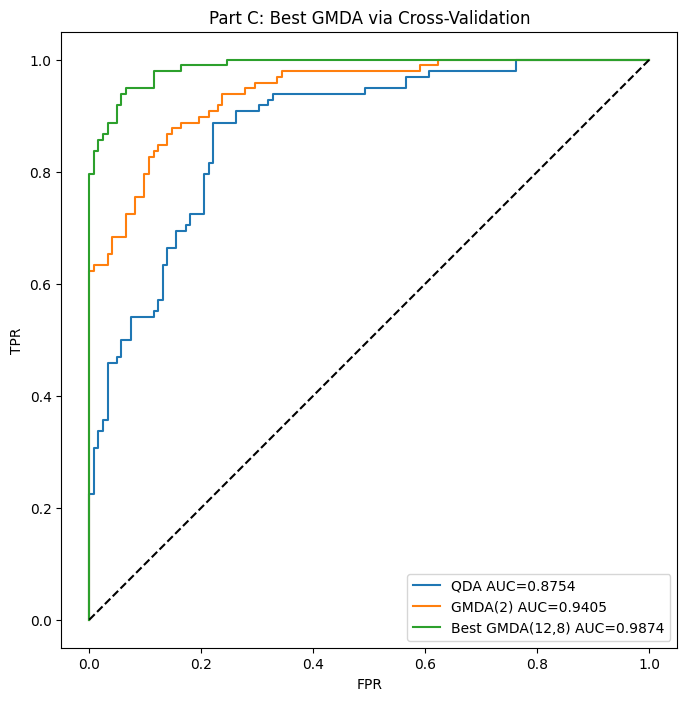

In [6]:
# Part C: Cross-validation for optimal number of Gaussian components
max_components = 12
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

X_train = data_train[features].values
y_train = lbls_train.values

best_auc = 0
best_n0 = 1
best_n1 = 1

for n0 in range(1, max_components + 1):
    for n1 in range(1, max_components + 1):
        aucs = []
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            tr_0 = X_tr[y_tr == 0]
            tr_1 = X_tr[y_tr == 1]
            p1 = y_tr.mean()
            p0 = 1 - p1

            try:
                g0 = GaussianMixture(n_components=n0, random_state=seed).fit(tr_0)
                g1 = GaussianMixture(n_components=n1, random_state=seed).fit(tr_1)
                pred_fn = make_predict_proba(g0, g1, pi0=p0, pi1=p1)
                proba = pred_fn(X_val)
                aucs.append(roc_auc_score(y_val, proba))
            except:
                aucs.append(0)

        mean_auc = np.mean(aucs)
        if mean_auc > best_auc:
            best_auc = mean_auc
            best_n0 = n0
            best_n1 = n1

print(f"Best n_components: class 0 = {best_n0}, class 1 = {best_n1}")
print(f"Best CV AUC: {best_auc:.4f}")

# Train best model on full training set
gm0_best = GaussianMixture(n_components=best_n0, random_state=seed).fit(train_0)
gm1_best = GaussianMixture(n_components=best_n1, random_state=seed).fit(train_1)
best_mgda = make_predict_proba(gm0_best, gm1_best, pi0=pi0, pi1=pi1)
best_test_proba = best_mgda(data_test[features].values)

best_pred_test = (best_test_proba > 0.5).astype(int)
print("\nBest GMDA Confusion Matrix (normalized):")
print(confusion_matrix(lbls_test, best_pred_test, normalize='true'))

best_mgda_auc = roc_auc_score(lbls_test, best_test_proba)
print(f"\nBest GMDA AUC: {best_mgda_auc:.4f}")

fprs_best, tprs_best, thds_best = roc_curve(lbls_test, best_test_proba)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_qda, tprs_qda, label=f'QDA AUC={qda_auc:.4f}')
ax.plot(fprs_mgda2, tprs_mgda2, label=f'GMDA(2) AUC={mgda2_auc:.4f}')
ax.plot(fprs_best, tprs_best, label=f'Best GMDA({best_n0},{best_n1}) AUC={best_mgda_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Part C: Best GMDA via Cross-Validation')
ax.legend()
plt.show()

## D.  

Assume that 1% of all the customers in your store try to pay with a counterfeit 100PLN bill. If you accept the counterfeit bill you loose 100PLN. If you reject a valid bill,  you may loose the purchase, you estimate this loss as 15PLN on average. For each of the three classifiers find the threshold that minimises your losses and calculates the minimum loss for each classifier. Show the optimal classifiers points on the ROC curves.

QDA: optimal threshold=0.9113, min loss=0.7755 PLN
GMDA(2): optimal threshold=0.7920, min loss=0.3776 PLN
Best GMDA(12,8): optimal threshold=0.8383, min loss=0.2041 PLN


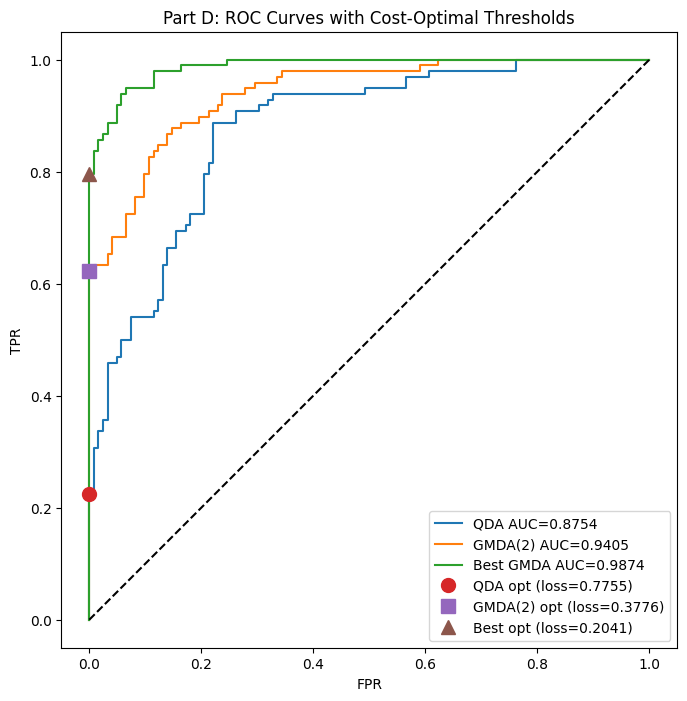

In [7]:
# Part D: Optimal threshold minimizing expected loss
# P(counterfeit) = 0.01, Cost_FN (accept counterfeit) = 100 PLN, Cost_FP (reject genuine) = 15 PLN
# Expected loss = P(c) * (1-TPR) * 100 + P(g) * FPR * 15

p_counterfeit = 0.01
p_genuine = 0.99
cost_fn = 100
cost_fp = 15

def find_optimal_threshold(fprs, tprs, thds):
    losses = p_counterfeit * (1 - tprs) * cost_fn + p_genuine * fprs * cost_fp
    idx = np.argmin(losses)
    return idx, losses[idx], thds[idx] if idx < len(thds) else thds[-1]

# QDA
idx_qda, loss_qda, thd_qda = find_optimal_threshold(fprs_qda, tprs_qda, thds_qda)
print(f"QDA: optimal threshold={thd_qda:.4f}, min loss={loss_qda:.4f} PLN")

# GMDA (2 components)
idx_mgda2, loss_mgda2, thd_mgda2 = find_optimal_threshold(fprs_mgda2, tprs_mgda2, thds_mgda2)
print(f"GMDA(2): optimal threshold={thd_mgda2:.4f}, min loss={loss_mgda2:.4f} PLN")

# Best GMDA
idx_best, loss_best, thd_best = find_optimal_threshold(fprs_best, tprs_best, thds_best)
print(f"Best GMDA({best_n0},{best_n1}): optimal threshold={thd_best:.4f}, min loss={loss_best:.4f} PLN")

# Plot ROC curves with optimal operating points
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_qda, tprs_qda, label=f'QDA AUC={qda_auc:.4f}')
ax.plot(fprs_mgda2, tprs_mgda2, label=f'GMDA(2) AUC={mgda2_auc:.4f}')
ax.plot(fprs_best, tprs_best, label=f'Best GMDA AUC={best_mgda_auc:.4f}')
ax.plot(fprs_qda[idx_qda], tprs_qda[idx_qda], 'o', markersize=10, label=f'QDA opt (loss={loss_qda:.4f})')
ax.plot(fprs_mgda2[idx_mgda2], tprs_mgda2[idx_mgda2], 's', markersize=10, label=f'GMDA(2) opt (loss={loss_mgda2:.4f})')
ax.plot(fprs_best[idx_best], tprs_best[idx_best], '^', markersize=10, label=f'Best opt (loss={loss_best:.4f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Part D: ROC Curves with Cost-Optimal Thresholds')
ax.legend(loc='lower right')
plt.show()